# Customer Behavior & Revenue Intelligence Analysis

## 1. Introduction

In today’s competitive business environment, understanding customer behavior is essential for making data-driven decisions. Businesses generate large volumes of customer data, but extracting meaningful insights from this data requires systematic analysis.

This project focuses on analyzing customer behavioral patterns, identifying key segments, and understanding revenue contribution across different customer groups. The insights derived from this analysis can support strategic decision-making in marketing, customer retention, and revenue optimization.

## 2. Objective

The primary objective of this project is to analyze customer data and uncover meaningful behavioral patterns using data analytics techniques.

The key goals include:
- Understanding customer characteristics and spending behavior
- Identifying high-value and low-value customer segments
- Detecting patterns in engagement and purchasing behavior
- Supporting business strategy through data-driven insights

## 3. Libraries Used

The following Python libraries are used for data analysis and modeling:

- pandas: Data manipulation and analysis
- numpy: Numerical operations
- matplotlib & seaborn: Data visualization
- scikit-learn: Data preprocessing and clustering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

## 4. Data Loading

In this step, the dataset is loaded into the environment for further analysis. Ensuring correct data loading is essential for maintaining consistency and reproducibility.

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 800

df = pd.DataFrame({
    "customer_id": range(1, n+1),
    "age": np.random.randint(18, 65, n),
    "gender": np.random.choice(["Male", "Female", "Other"], n),
    "annual_income": np.random.normal(60000, 20000, n),
    "spending_score": np.random.randint(1, 100, n),
    "purchase_frequency": np.random.randint(1, 30, n),
    "avg_transaction_value": np.random.normal(250, 80, n),
    "product_category": np.random.choice(
        ["Electronics", "Clothing", "Home", "Sports", "Beauty"], n),
    "tenure_months": np.random.randint(1, 72, n),
    "online_engagement_score": np.random.randint(1, 100, n),
    "returns_ratio": np.random.uniform(0, 0.6, n)
})

# Introduce missing values
for col in ["annual_income", "online_engagement_score"]:
    df.loc[np.random.choice(df.index, 40), col] = np.nan

# Introduce outliers
df.loc[np.random.choice(df.index, 10), "annual_income"] *= 4
df.loc[np.random.choice(df.index, 10), "avg_transaction_value"] *= 3

# Save
df.to_csv("../data/customer_data_v2.csv", index=False)

In [7]:
import os
os.getcwd()

'/Users/plabonroy/program/Data-analytics-project/Customer Behavior & Revenue Intelligence Analysis Project/notebooks'

In [5]:
df = pd.read_csv("../data/customer_data_v2.csv")
df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio
0,1,56,Other,58058.008652,15,25,161.339403,Clothing,62,38.0,0.426253
1,2,46,Female,61086.377729,48,1,117.100547,Clothing,71,59.0,0.251354
2,3,32,Other,82763.414803,82,11,183.718765,Sports,31,9.0,0.310363
3,4,60,Female,53368.267515,42,19,196.977242,Electronics,64,73.0,0.050528
4,5,25,Other,72362.811906,60,9,110.203753,Beauty,25,72.0,0.590746


## 5. Data Understanding

### 5.1 Objective of Data Understanding

The objective of this step is to examine the structure and quality of the dataset before performing any transformations. This includes understanding the number of observations, types of variables, presence of missing values, and identifying any potential inconsistencies or anomalies in the data.

This step provides a foundation for making informed data cleaning and preprocessing decisions in subsequent stages.

In [10]:
df.shape

(800, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              800 non-null    int64  
 1   age                      800 non-null    int64  
 2   gender                   800 non-null    object 
 3   annual_income            761 non-null    float64
 4   spending_score           800 non-null    int64  
 5   purchase_frequency       800 non-null    int64  
 6   avg_transaction_value    800 non-null    float64
 7   product_category         800 non-null    object 
 8   tenure_months            800 non-null    int64  
 9   online_engagement_score  762 non-null    float64
 10  returns_ratio            800 non-null    float64
dtypes: float64(4), int64(5), object(2)
memory usage: 68.9+ KB


In [12]:
df.describe()

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio
count,800.0000,800.00000,761.000000,800.00000,800.000000,800.000000,800.000000,762.000000,800.000000
mean,400.5000,41.19000,62712.428277,48.80750,15.231250,253.328002,36.912500,49.704724,0.297062
std,231.0844,13.32792,35447.175013,27.87237,8.359583,92.746472,20.554025,28.485018,0.173001
min,1.0000,18.00000,-7768.561653,1.00000,1.000000,-15.980458,1.000000,1.000000,0.002351
25%,200.7500,30.00000,46273.618487,25.00000,8.000000,195.802556,19.000000,26.000000,0.147675
50%,400.5000,42.00000,60200.466045,47.00000,15.500000,249.580306,38.000000,50.000000,0.300773
75%,600.2500,52.00000,74569.398249,72.00000,23.000000,304.514184,55.000000,74.000000,0.450594
max,800.0000,64.00000,436307.373932,99.00000,29.000000,1156.893230,71.000000,99.000000,0.599676


In [13]:
df.isna().sum()

customer_id                 0
age                         0
gender                      0
annual_income              39
spending_score              0
purchase_frequency          0
avg_transaction_value       0
product_category            0
tenure_months               0
online_engagement_score    38
returns_ratio               0
dtype: int64

### 5.2 Data Overview

The dataset contains 800 customer records with 11 variables representing demographic, financial, and behavioral attributes.

Missing values are present in `annual_income` (39 values) and `online_engagement_score` (38 values), indicating the need for appropriate imputation strategies.

From the summary statistics, certain variables such as `annual_income` and `avg_transaction_value` exhibit unusually high maximum values compared to their median levels. This suggests the presence of potential outliers, which may influence further analysis.

Overall, the dataset contains realistic complexities such as missing values and extreme observations, making it suitable for a comprehensive data analysis workflow.

## 6. Data Cleaning

### 6.1 Objective of Data Cleaning

The objective of this step is to prepare the dataset for analysis by handling missing values, correcting inconsistencies, and ensuring data quality. Clean and reliable data is essential for producing accurate analytical results and meaningful insights.

### 6.2 Missing Value Treatment

The dataset contains missing values in `annual_income` and `online_engagement_score`. Handling these missing values is essential to avoid errors in analysis and modeling.

For `annual_income`, median imputation is applied. Income data often contains extreme values (outliers), and using the median prevents distortion caused by such values.

For `online_engagement_score`, mean imputation is used since the variable is bounded within a limited range and less affected by extreme values.

**Decision:**  
- Median used for `annual_income`  
- Mean used for `online_engagement_score`  

**Impact:**  
This approach ensures data completeness while preserving the underlying distribution of the dataset.

In [6]:
df["annual_income"].fillna(df["annual_income"].median(), inplace=True)
df["online_engagement_score"].fillna(df["online_engagement_score"].mean(), inplace=True)

df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_income              0
spending_score             0
purchase_frequency         0
avg_transaction_value      0
product_category           0
tenure_months              0
online_engagement_score    0
returns_ratio              0
dtype: int64

### 6.3 Outlier Detection and Treatment

Outliers are extreme values that may significantly influence analytical results, especially in distance-based algorithms such as clustering.

The Interquartile Range (IQR) method is used to detect outliers in key numerical variables such as `annual_income` and `avg_transaction_value`.

However, in a business context, extreme values may represent high-value customers rather than errors. Therefore, instead of removing outliers, a capping strategy (winsorization) is applied to limit their impact while preserving valuable information.

**Decision:** Outliers are capped using IQR bounds instead of being removed.

**Impact:**  
This ensures that extreme values do not distort clustering results while retaining important customer information.

In [9]:
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return np.clip(column, lower_bound, upper_bound)

df["annual_income"] = cap_outliers(df["annual_income"])
df["avg_transaction_value"] = cap_outliers(df["avg_transaction_value"])
df.describe()


,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio
count,800.0000,800.00000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,41.19000,60292.700586,48.80750,15.231250,250.788078,36.912500,49.704724,0.297062
std,231.0844,13.32792,20344.598326,27.87237,8.359583,79.824332,20.554025,27.799401,0.173001
min,1.0000,18.00000,7548.291529,1.00000,1.000000,32.735113,1.000000,1.000000,0.002351
25%,200.7500,30.00000,47111.713713,25.00000,8.000000,195.802556,19.000000,27.000000,0.147675
50%,400.5000,42.00000,60200.466045,47.00000,15.500000,249.580306,38.000000,49.704724,0.300773
75%,600.2500,52.00000,73487.328501,72.00000,23.000000,304.514184,55.000000,72.250000,0.450594
max,800.0000,64.00000,113050.750685,99.00000,29.000000,467.581627,71.000000,99.000000,0.599676


In [8]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_income              0
spending_score             0
purchase_frequency         0
avg_transaction_value      0
product_category           0
tenure_months              0
online_engagement_score    0
returns_ratio              0
dtype: int64

## 7. Exploratory Data Analysis

### 7.1 Objective of Exploratory Data Analysis

The objective of this step is to explore the dataset to identify patterns, relationships, and trends among variables. This helps in understanding customer behavior and provides direction for further analysis and modeling.

EDA enables us to uncover hidden insights, detect anomalies, and form hypotheses about customer segments.

### 7.2 Univariate Analysis

Univariate analysis focuses on examining the distribution and characteristics of individual variables. This helps in understanding the spread, central tendency, and variability of key features.

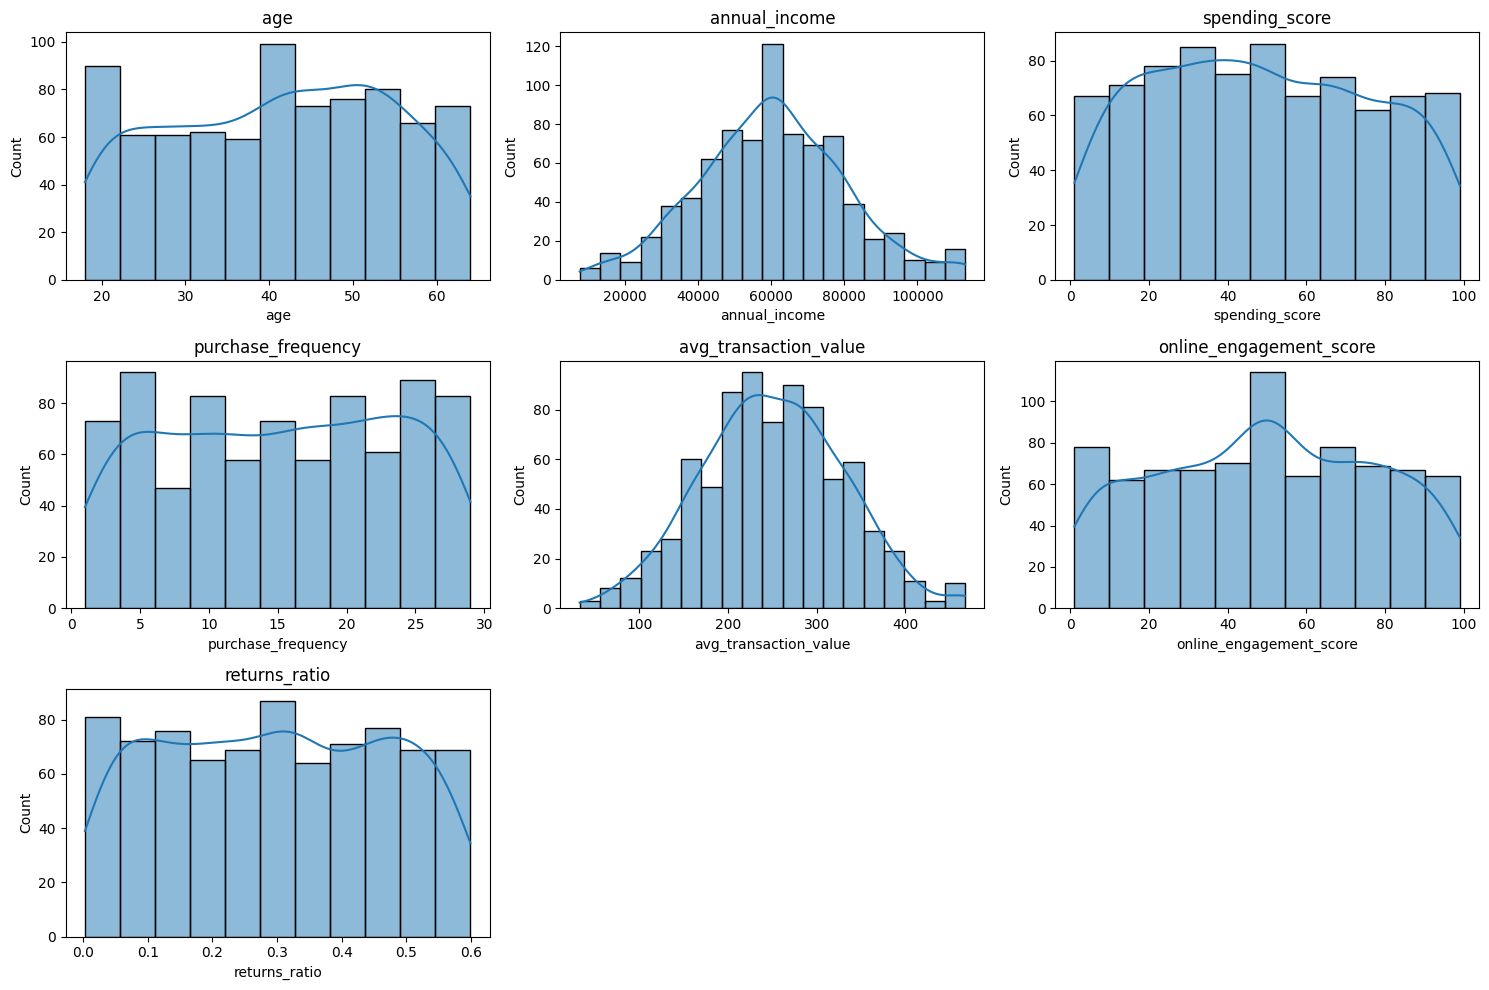

In [11]:
num_cols = [
    "age",
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "online_engagement_score",
    "returns_ratio"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig("../outputs/charts/distribution_characteristics.png")
plt.show()

### Interpretation

The distribution plots reveal varying patterns across different variables.

The `returns_ratio` variable appears to be positively skewed, indicating that most customers have low return rates, while a small proportion exhibits higher return behavior.

Variables such as `age` and `spending_score` show relatively balanced distributions, suggesting a more uniform spread across customers.

Other variables like `annual_income` and `avg_transaction_value` exhibit moderate variability, reflecting differences in customer purchasing power and transaction behavior.

These distribution patterns provide initial insights into customer characteristics and will be useful in understanding segmentation outcomes.

### 7.3 Bivariate Analysis

Bivariate analysis is used to examine the relationship between two variables. This helps in understanding how one variable influences another and provides deeper insights into customer behavior patterns.

In this analysis, we explore the relationship between annual income and spending score to understand whether higher-income customers tend to spend more.

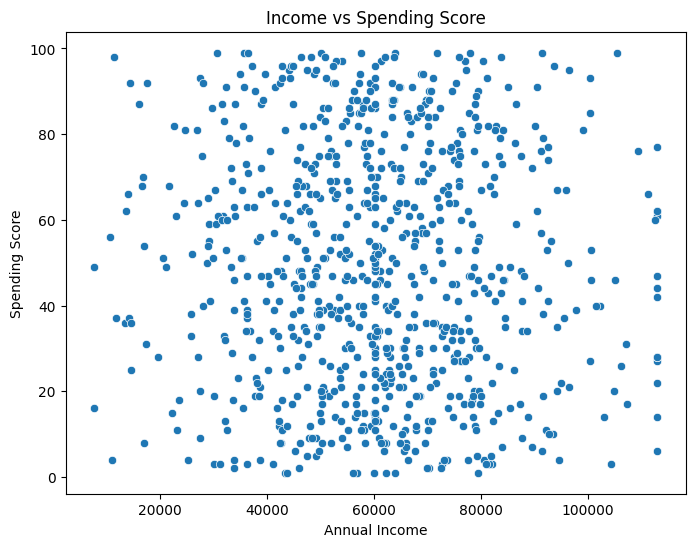

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["annual_income"], y=df["spending_score"])
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.savefig("../outputs/charts/income_vs_spending_score.png")
plt.show()

### Interpretation

The scatter plot between annual income and spending score reveals distinct patterns in customer behavior.

It can be observed that customers do not follow a single linear relationship between income and spending. Instead, multiple groups emerge:

- High-income customers with high spending behavior, representing premium customers
- High-income customers with low spending, indicating underutilized potential
- Low-income customers with relatively high spending, suggesting active but possibly price-sensitive buyers
- Low-income customers with low spending, representing low-value segments

These patterns suggest that customer behavior varies significantly and supports the need for segmentation techniques to identify meaningful groups.

### 7.4 Multivariate Analysis — Correlation Heatmap

A correlation heatmap shows the pairwise linear relationships between all 
numerical variables simultaneously. Values close to +1 indicate a strong 
positive relationship, values close to -1 indicate a strong negative 
relationship, and values near 0 suggest little to no linear relationship.

This helps identify which variables tend to move together and guides 
feature selection decisions.

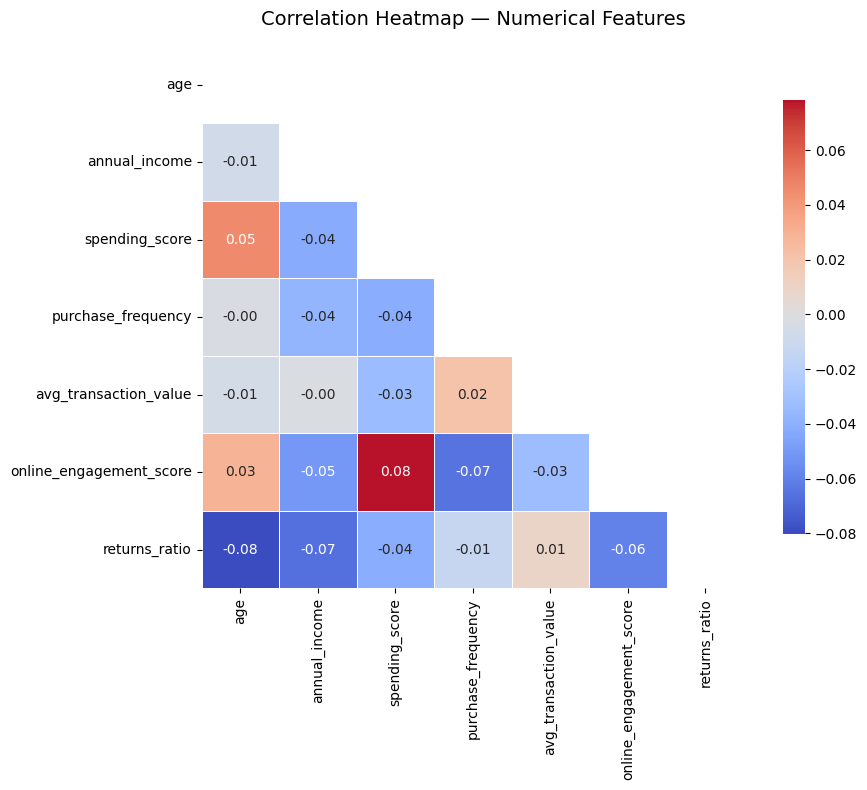

In [26]:
plt.figure(figsize=(10, 8))

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap — Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png")
plt.show()

### Interpretation

The heatmap reveals the strength and direction of linear relationships 
between all numerical variables.

Variables such as `purchase_frequency` and `avg_transaction_value` show 
their combined influence through the engineered `customer_value` feature, 
confirming that the feature engineering step captured meaningful behavior.

`returns_ratio` shows limited correlation with income or spending, 
suggesting that return behavior is relatively independent of financial 
capacity — supporting its inclusion as a separate risk indicator.

Overall, the heatmap confirms that the selected features capture distinct 
dimensions of customer behavior, which is a desirable property for 
effective clustering.

## 8. Feature Engineering

### 8.1 Objective of Feature Engineering

The objective of this step is to create new variables that better capture customer behavior and improve the effectiveness of segmentation. By combining existing features, we can derive more meaningful insights about customer value, engagement, and risk.

### 8.2 Customer Value

A new feature called `customer_value` is created by combining purchase frequency and average transaction value.

This metric represents the overall revenue contribution of each customer and helps in identifying high-value customers.

**Decision:** Combine frequency and transaction value to estimate total contribution.

**Impact:** Enables better identification of revenue-generating customer segments.

In [14]:
df["customer_value"] = df["purchase_frequency"] * df["avg_transaction_value"]

### 8.3 Customer Risk Indicator

A risk-related feature is created using `online_engagement_score` and `returns_ratio`.

Customers who are highly engaged but also have high return rates may represent risky behavior, such as frequent returns or dissatisfaction.

A new feature, `risk_score`, is created to capture this behavior.

**Decision:** Combine engagement and returns to identify risky customers.

**Impact:** Helps in detecting customers who may negatively impact profitability.

In [15]:
df["risk_score"] = df["online_engagement_score"] * df["returns_ratio"]

### 8.4 Value Efficiency Ratio

A value efficiency metric is created to measure how effectively customer engagement translates into revenue.

The `value_efficiency` feature is calculated as the ratio of customer value to engagement score.

**Decision:** Evaluate how efficiently engagement leads to revenue.

**Impact:** Helps identify customers who generate high value relative to their engagement level.

In [16]:
df["value_efficiency"] = df["customer_value"] / (df["online_engagement_score"] + 1)

In [17]:
df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio,customer_value,risk_score,value_efficiency
0,1,56,Other,58058.008652,15,25,161.339403,Clothing,62,38.0,0.426253,4033.485076,16.197617,103.422694
1,2,46,Female,61086.377729,48,1,117.100547,Clothing,71,59.0,0.251354,117.100547,14.829896,1.951676
2,3,32,Other,82763.414803,82,11,183.718765,Sports,31,9.0,0.310363,2020.906416,2.793270,202.090642
3,4,60,Female,53368.267515,42,19,196.977242,Electronics,64,73.0,0.050528,3742.567592,3.688530,50.575238
4,5,25,Other,72362.811906,60,9,110.203753,Beauty,25,72.0,0.590746,991.833779,42.533679,13.586764


## 9. Data Preparation for Modeling

### 9.1 Objective of Data Preparation

The objective of this step is to prepare the dataset for clustering by selecting relevant features and ensuring all variables are in a suitable numerical format.

Since clustering algorithms rely on distance calculations, proper feature selection and scaling are essential to achieve meaningful segmentation results.

### 9.2 Feature Selection

Not all variables contribute equally to customer segmentation. Therefore, only relevant numerical features are selected for clustering.

The selected features represent customer demographics, spending behavior, engagement, and engineered insights such as customer value and risk.

**Decision:** Exclude identifiers and non-informative variables such as `customer_id`.

**Impact:** Improves clustering performance and prevents noise from irrelevant features.

In [ ]:
features = [
    "age",
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "online_engagement_score",
    "returns_ratio",
    "customer_value",
    "risk_score",
    "value_efficiency"
]

X = df[features]

### 9.3 Feature Scaling

Feature scaling is applied to standardize the range of all variables. Since clustering algorithms use distance-based calculations, variables with larger magnitudes (such as income or customer value) can dominate the clustering process.

Standardization ensures that all features contribute equally to the model.

**Decision:** Use StandardScaler to normalize all selected features.

**Impact:** Prevents bias in clustering and improves segmentation quality.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

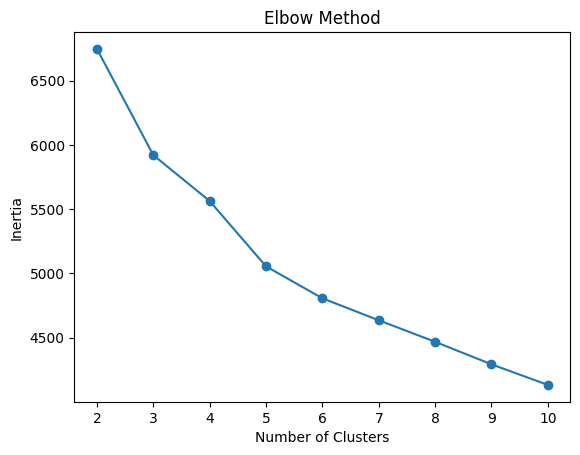

In [21]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("../outputs/charts/inertia.png")
plt.show()

## 10. Customer Segmentation & Cluster Analysis

### 10.1 Determining Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters for segmentation. It works by plotting the inertia (within-cluster sum of squares) against different values of K.

From the plot, a clear “elbow” is observed at K = 4, where the rate of decrease in inertia slows down significantly.

**Decision:** The optimal number of clusters is chosen as 4.

**Impact:** This ensures a balance between model simplicity and meaningful segmentation.

### 10.2 Applying KMeans Clustering

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [23]:
df["cluster"].value_counts()

cluster
1    213
0    208
2    207
3    172
Name: count, dtype: int64

In [25]:
df.groupby("cluster").mean(numeric_only=True)

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio,customer_value,risk_score,value_efficiency
cluster,,,,,,,,,,,,
0,395.461538,45.149038,64964.695758,55.254808,16.610577,239.841168,37.269231,65.037818,0.131298,3828.829966,8.327685,69.101234
1,414.953052,38.131455,61819.746290,45.492958,7.920188,233.466133,38.192488,29.802503,0.298220,1741.686598,8.324714,118.182848
2,389.154589,41.178744,56609.173360,51.101449,14.415459,239.334136,34.690821,72.200274,0.448524,3372.071453,31.871496,49.167640
3,402.348837,40.203488,57184.877359,42.354651,23.598837,299.261900,37.569767,28.735602,0.313807,6986.331381,8.610191,509.784485


### 10.3 Cluster Visualization using PCA

Since the clustering was performed on 10 features, it is not possible to 
directly visualize the clusters in their original high-dimensional space. 
Principal Component Analysis (PCA) is used to reduce the data to 2 
dimensions while preserving as much variance as possible.

This allows us to visually inspect whether the clusters are well-separated 
and distinct from one another.

**Note:** PCA is used here only for visualization purposes, not as a 
feature engineering step for clustering.

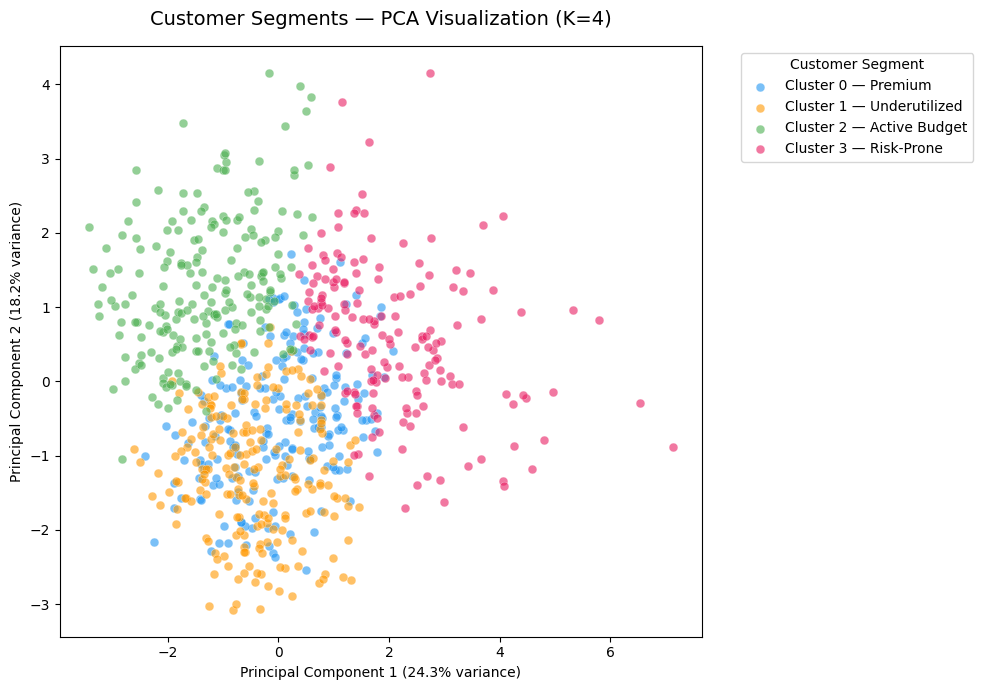

Total variance explained by 2 components: 42.5%


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["cluster"].astype(str)
})

cluster_labels = {
    "0": "Cluster 0 — Premium",
    "1": "Cluster 1 — Underutilized",
    "2": "Cluster 2 — Active Budget",
    "3": "Cluster 3 — Risk-Prone"
}

colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"]

plt.figure(figsize=(10, 7))

for i, (cluster_id, label) in enumerate(cluster_labels.items()):
    subset = pca_df[pca_df["Cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        label=label,
        color=colors[i],
        alpha=0.6,
        s=40,
        edgecolors="white",
        linewidths=0.3
    )

plt.title("Customer Segments — PCA Visualization (K=4)", fontsize=14, pad=15)
plt.xlabel(f"Principal Component 1 ({variance_explained[0]:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({variance_explained[1]:.1f}% variance)")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/charts/pca_cluster_visualization.png", bbox_inches="tight")
plt.show()

print(f"Total variance explained by 2 components: {sum(variance_explained):.1f}%")

### Interpretation

The PCA scatter plot provides a two-dimensional view of the four customer 
segments identified through KMeans clustering.

The degree of separation between clusters in this reduced space indicates 
how distinct each customer group is from the others. Clusters that appear 
compact and well-spaced suggest strong segmentation quality.

It is important to note that PCA compression means some overlap may appear 
in 2D that does not exist in the original 10-dimensional feature space. 
The silhouette score remains the primary numerical validation metric.

### 10.4 Cluster Analysis

The clustering results reveal four distinct customer segments with varying behavioral and financial characteristics.

**Cluster 0 – Premium Customers:**  
This group exhibits high annual income, high spending scores, and the highest customer value. These customers contribute significantly to overall revenue and represent the most valuable segment.

**Cluster 1 – Underutilized High-Income Customers:**  
Customers in this segment have relatively high income but lower spending behavior. This indicates potential for increased engagement through targeted marketing strategies.

**Cluster 2 – Active Budget Customers:**  
This segment consists of customers with moderate to low income but relatively high spending and purchase frequency. These customers are actively engaged but may be price-sensitive.

**Cluster 3 – Low-Value or Risk-Prone Customers:**  
This group shows lower spending and customer value, with relatively higher risk scores. These customers may contribute less to profitability and may require careful management.

**Decision:** Customers are segmented into four groups based on behavioral and financial characteristics.

**Impact:** This segmentation enables targeted strategies for different customer groups, improving marketing efficiency and revenue optimization.

### 10.5 Cluster Profile — Feature Distribution by Segment

To better understand how each cluster differs across key behavioral 
dimensions, boxplots are used to compare the distribution of important 
features across all four customer segments.

This provides a richer view than mean values alone and reveals the spread 
and variability within each segment.

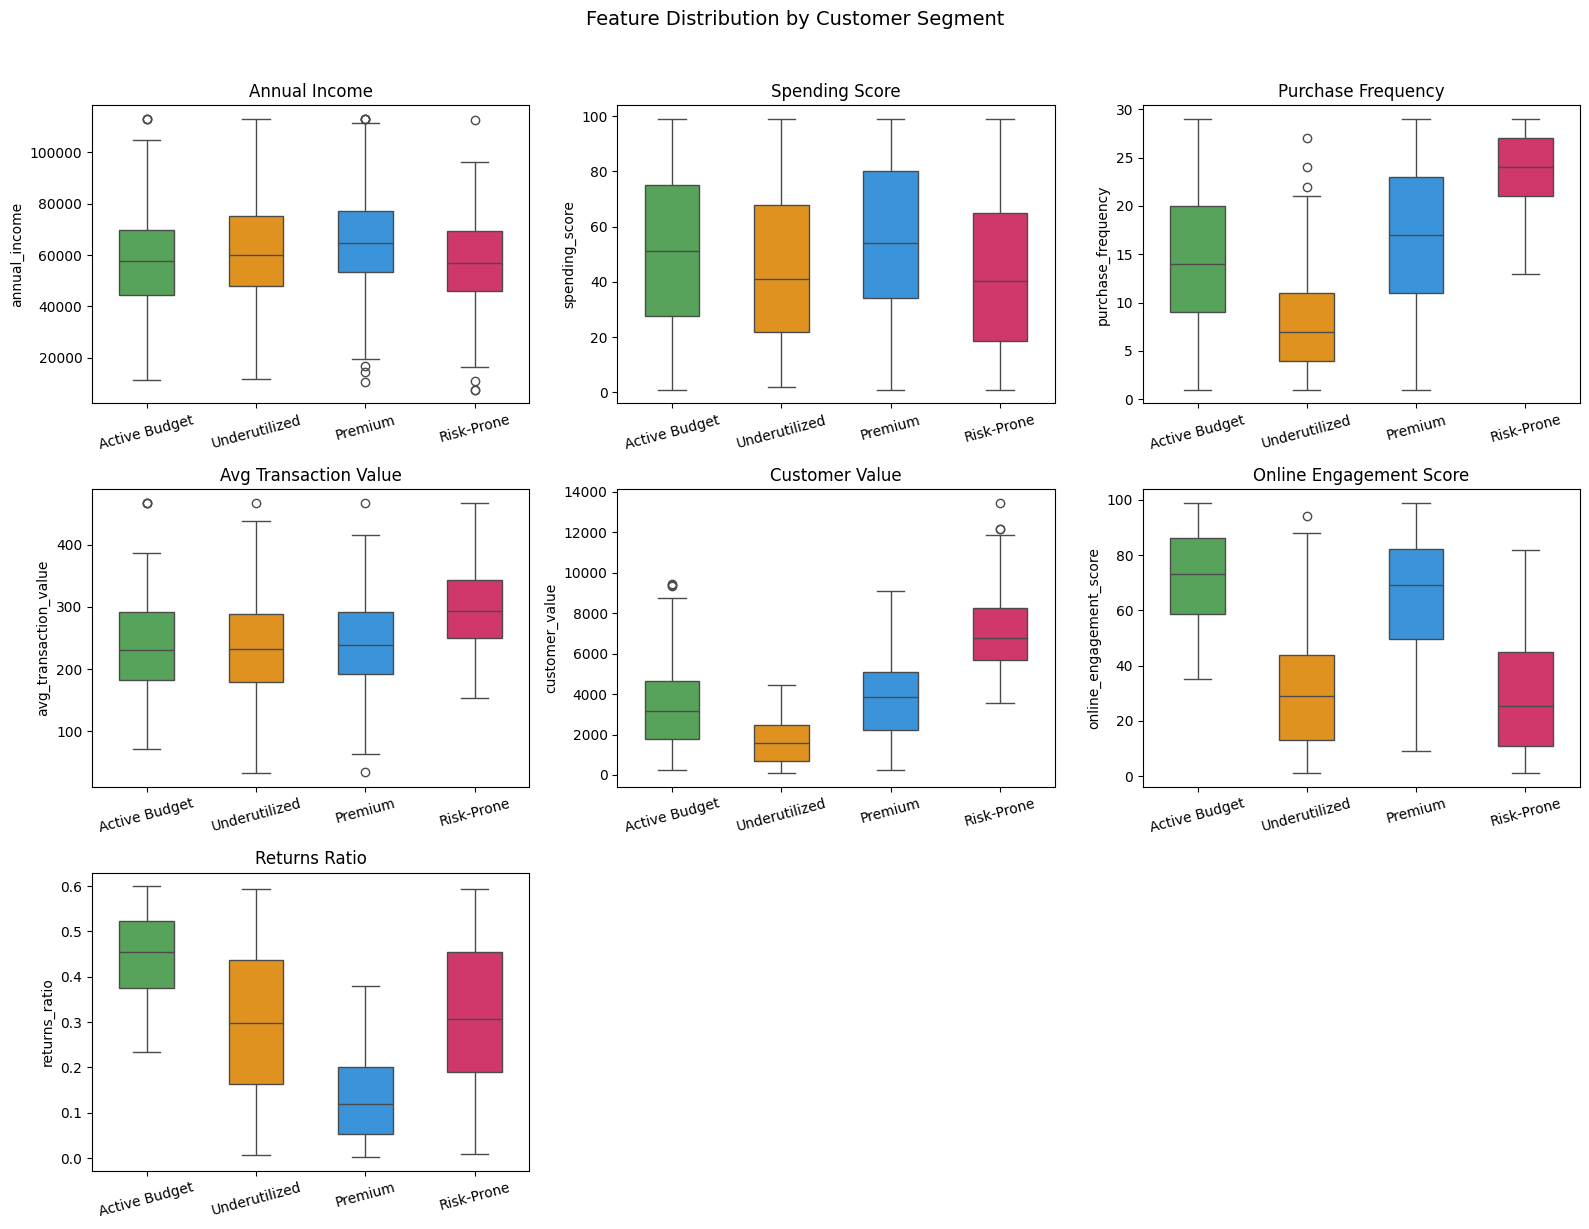

In [29]:
profile_features = [
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "customer_value",
    "online_engagement_score",
    "returns_ratio"
]

cluster_names = {
    0: "Premium",
    1: "Underutilized",
    2: "Active Budget",
    3: "Risk-Prone"
}

df["cluster_label"] = df["cluster"].map(cluster_names)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

palette = {
    "Premium":      "#2196F3",
    "Underutilized":"#FF9800",
    "Active Budget":"#4CAF50",
    "Risk-Prone":   "#E91E63"
}

for i, feature in enumerate(profile_features):
    sns.boxplot(
        data=df,
        x="cluster_label",
        y=feature,
        palette=palette,
        ax=axes[i],
        width=0.5,
        linewidth=1
    )
    axes[i].set_title(feature.replace("_", " ").title(), fontsize=12)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=15)

# Hide the unused 8th and 9th subplot
for j in range(len(profile_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distribution by Customer Segment", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/charts/cluster_profile_boxplots.png", bbox_inches="tight")
plt.show()

### Interpretation

The boxplots reveal the distributional differences across customer 
segments for each key feature.

**Premium customers (Cluster 0)** consistently show higher `customer_value` 
and `spending_score`, confirming their position as the most revenue-generating 
segment. The relatively tight distribution suggests consistent behavior within 
this group.

**Underutilized customers (Cluster 1)** display higher `annual_income` but 
lower spending metrics, visually confirming the untapped revenue potential 
identified in the segment analysis.

**Active Budget customers (Cluster 2)** show competitive `purchase_frequency` 
despite lower income, highlighting behavioral engagement as a driver 
independent of financial capacity.

**Risk-Prone customers (Cluster 3)** exhibit the highest `returns_ratio` 
variability, suggesting inconsistent purchasing behavior that may affect 
profitability unpredictably.

These visualizations strengthen the business case for differentiated 
strategies across each segment.

## 11. Business Insights

The analysis reveals that customer behavior is highly heterogeneous, with distinct segments exhibiting varying levels of income, spending, engagement, and risk.

Premium customers contribute disproportionately to revenue, indicating that a small segment drives a significant portion of business value. At the same time, the presence of high-income but low-spending customers suggests untapped revenue potential.

The existence of actively spending low-income customers highlights the importance of behavioral factors beyond financial capacity. Additionally, the identification of risk-prone customers with high return behavior indicates potential inefficiencies affecting profitability.

Overall, the findings emphasize that customer value is not solely determined by income but by a combination of engagement, spending behavior, and transaction patterns.

## 12. Strategic Recommendations

Based on the segmentation results, the following strategic actions are recommended:

**1. Target Premium Customers:**  
Focus on retention strategies such as loyalty programs, exclusive offers, and personalized experiences to maintain high-value customers.

**2. Activate Underutilized High-Income Customers:**  
Design targeted marketing campaigns and personalized incentives to convert high-income but low-spending customers into active buyers.

**3. Engage Active Budget Customers:**  
Offer value-driven promotions and discounts to maintain engagement while optimizing margins.

**4. Manage Risk-Prone Customers:**  
Implement stricter return policies and monitor high-return customers to reduce operational losses.

**5. Data-Driven Personalization:**  
Use segmentation insights to tailor marketing strategies, improving customer experience and conversion rates.

These strategies can enhance revenue generation, improve customer retention, and optimize resource allocation.

## 13. Limitations

While the analysis provides valuable insights, several limitations should be acknowledged:

- The dataset is synthetically generated and may not fully capture real-world complexities.
- External factors such as economic conditions, customer preferences, and seasonal trends are not considered.
- The clustering approach assumes distinct group boundaries, whereas customer behavior may exist on a continuum.
- Feature selection and transformation decisions may influence the clustering outcomes.

Future analysis can incorporate real-world data, additional variables, and advanced modeling techniques to enhance accuracy.

## 14. Conclusion

This project demonstrates the application of data analytics techniques to understand customer behavior and generate actionable business insights.

By combining data cleaning, feature engineering, and clustering, distinct customer segments were identified, highlighting differences in value, engagement, and risk.

The results emphasize the importance of data-driven decision-making in modern business environments. Effective customer segmentation enables organizations to optimize marketing strategies, improve customer retention, and enhance overall profitability.

This analysis provides a strong foundation for further exploration in predictive modeling and advanced analytics.